In [1]:
file_read = "001_refit"
file_write = "002_RMSE"

In [2]:
import polars as pl

df_preds = pl.read_parquet(f"{file_read}_preds.parquet")

In [3]:
df_preds

n_features,pyridone,backbone,beta_av_logit,beta_av_logit_pred
i32,i64,i64,f64,f64
51,0,0,0.055549,0.083511
51,0,1,0.061619,0.029529
51,0,2,-0.086761,-0.047476
51,0,3,-0.086245,-0.058228
51,0,4,-0.242775,-0.019353
…,…,…,…,…
5,12,3,-0.155744,-0.062729
5,12,4,-0.010116,-0.092678
5,12,5,-0.04161,-0.143899


In [4]:
column_target = "beta_av"
column_target_scaled = "beta_av_logit"
column_pred = f"{column_target}_pred"
column_pred_scaled = f"{column_target_scaled}_pred"

In [5]:
df_preds = df_preds.with_columns(
    (100 / (1 + (-pl.col(column_target_scaled)).exp())).alias(column_target),
    (100 / (1 + (-pl.col(column_pred_scaled)).exp())).alias(column_pred),
)

In [6]:
df_preds

n_features,pyridone,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i64,i64,f64,f64,f64,f64
51,0,0,0.055549,0.083511,51.388357,52.08657
51,0,1,0.061619,0.029529,51.539999,50.738179
51,0,2,-0.086761,-0.047476,47.832328,48.813325
51,0,3,-0.086245,-0.058228,47.845209,48.544723
51,0,4,-0.242775,-0.019353,43.960253,49.5162
…,…,…,…,…,…,…
5,12,3,-0.155744,-0.062729,46.114252,48.43228
5,12,4,-0.010116,-0.092678,49.74711,47.6847
5,12,5,-0.04161,-0.143899,48.959898,46.408724


In [7]:
df_rmse = (
    df_preds
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [8]:
df_rmse

n_features,beta_av_rmse
i32,f64
51,4.661881
50,4.6427
49,4.622832
48,4.592383
47,4.555226
…,…
9,4.30537
8,4.836002
7,5.233835


In [9]:
df_rmse_min = df_rmse.filter(
    pl.col(f"{column_target}_rmse") == pl.col(f"{column_target}_rmse").min()
)

In [10]:
df_rmse_min

n_features,beta_av_rmse
i32,f64
11,3.861018


In [11]:
n_features_min = df_rmse_min["n_features"][0]

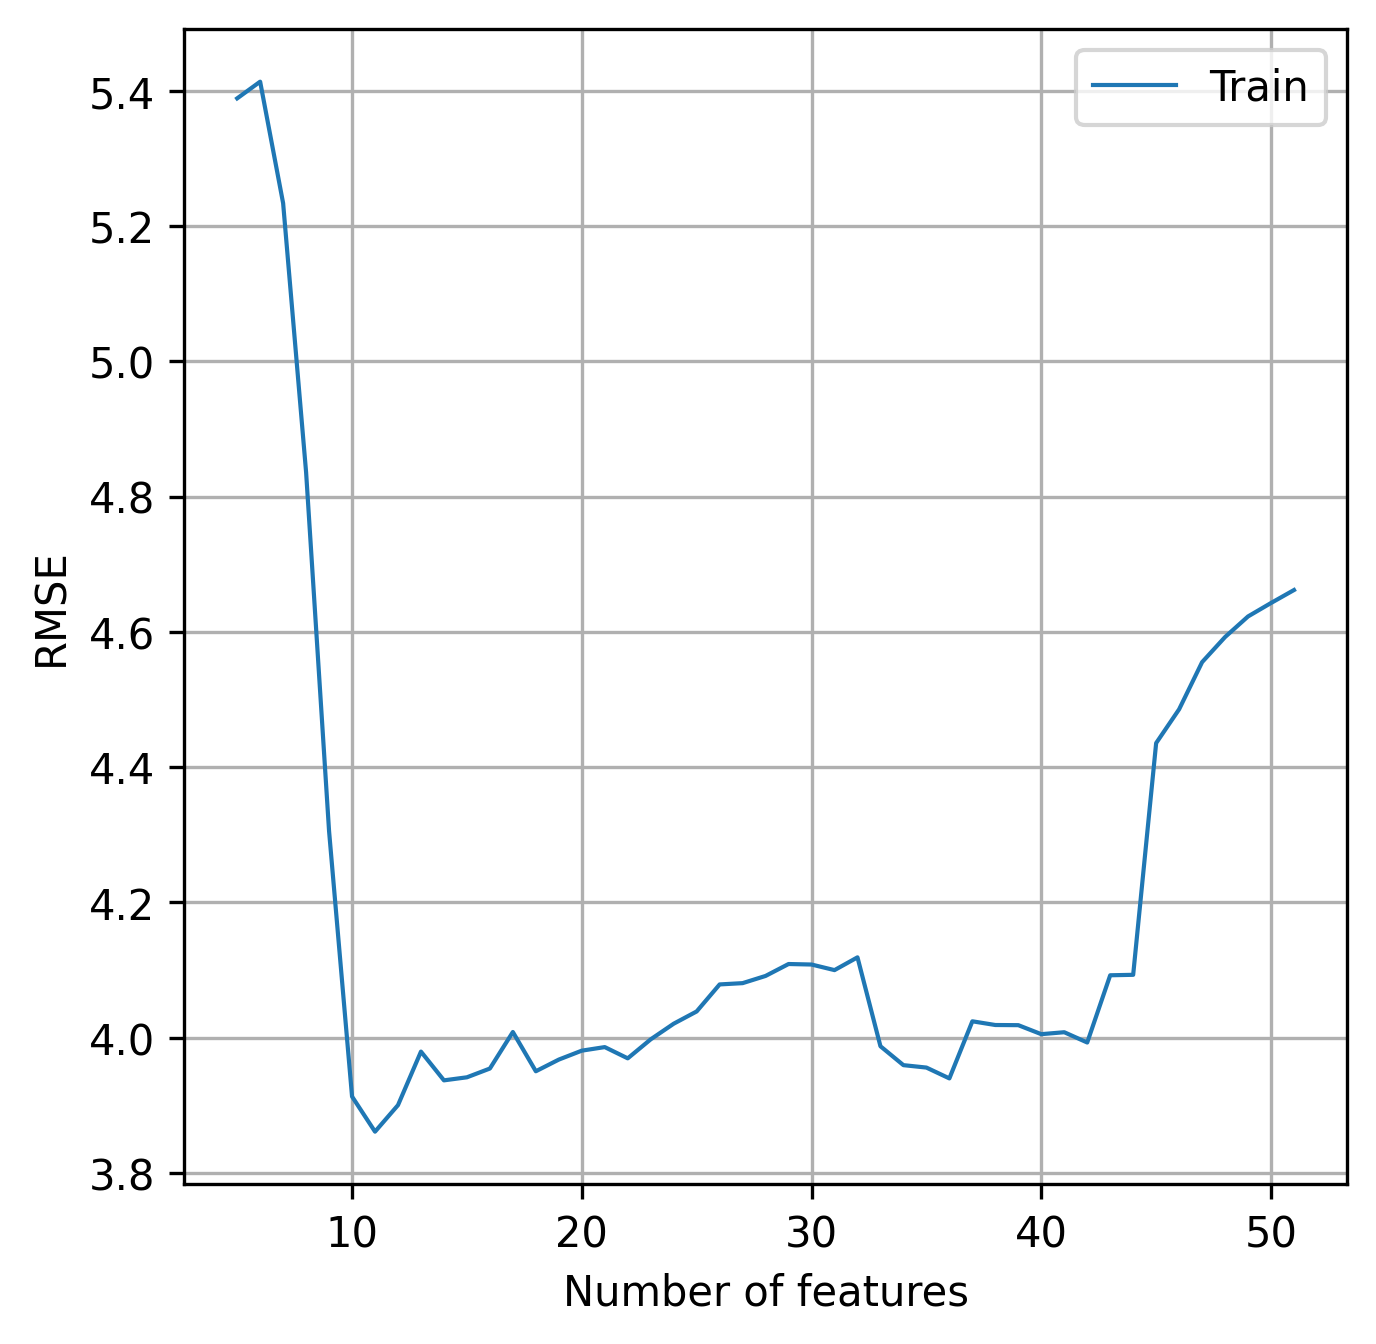

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(
    df_rmse["n_features"],
    df_rmse[f"{column_target}_rmse"],
    c="tab:blue",
    label="Train",
    lw=1
)

ax.set_xlabel("Number of features")
ax.set_ylabel("RMSE")

ax.grid()
ax.legend()

plt.savefig(
    f"{file_write}_plot.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()